<a href="https://colab.research.google.com/github/SathyaPrakashD/Classical-ML-Pipeline/blob/main/sklearn_digits_workout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CHECKPOINT 1 — Load & Inspect Data
# ============================================================

from sklearn.datasets import load_digits
import pandas as pd

# Step 1 — Load the dataset
data = load_digits()
#print(data.feature_names)
# Step 2 — Wrap features into a DataFrame
# Hint: data.feature_names gives you column names
df = pd.DataFrame(data.data, columns=data.feature_names)


# Step 3 — Add the target column
df['target'] = data.target

df.head(5)


# Step 4 — Print basic info
print("Shape:", df.shape)          # how many rows and columns?
print("Classes:", data.target_names)        # what are the 3 wine classes called?
print("Class counts:\n", df['target'].value_counts())

# Step 5 — Preview first 5 rows
#print(df.___)jacob

Shape: (1797, 65)
Classes: [0 1 2 3 4 5 6 7 8 9]
Class counts:
 target
3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64


In [ ]:
# ============================================================
# CHECKPOINT 2 — Split first, then Scale (correct order)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1 — Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Step 2 — Split BEFORE scaling
# test_size=0.2 means 20% test, 80% train
# random_state fixes the random split so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Step 3 — Fit scaler on TRAIN only
scaler = StandardScaler()
scaler.fit(X_train)             # learns mean & std from train only

# Step 4 — Transform both using train's stats
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)



# Step 5 — Verify scaling worked
X_train_df_before = pd.DataFrame(X_train, columns=X.columns)
print("\Before scaling (train set):")
print(X_train_df_before.head())

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("\nAFTER scaling (train set):")
print(X_train_df.head())
#print(X_train_df[['alcohol', 'magnesium', 'proline']].describe().round(2))

Train size: 1437
Test size: 360
\Before scaling (train set):
      pixel_0_0  pixel_0_1  pixel_0_2  pixel_0_3  pixel_0_4  pixel_0_5  \
1734        0.0        0.0        3.0       14.0        1.0        0.0   
855         0.0        0.0        9.0        9.0        4.0        0.0   
1642        0.0        0.0        0.0       10.0       13.0        3.0   
175         0.0        1.0       10.0       16.0       16.0       11.0   
925         0.0        0.0        6.0       14.0       13.0        3.0   

      pixel_0_6  pixel_0_7  pixel_1_0  pixel_1_1  ...  pixel_6_6  pixel_6_7  \
1734        0.0        0.0        0.0        0.0  ...       11.0        0.0   
855         0.0        0.0        0.0        0.0  ...        0.0        0.0   
1642        0.0        0.0        0.0        0.0  ...        1.0        0.0   
175         0.0        0.0        0.0        5.0  ...        4.0        0.0   
925         0.0        0.0        0.0        0.0  ...        2.0        0.0   

      pixel_7_0  pi

<>:35: SyntaxWarning: invalid escape sequence '\B'
<>:35: SyntaxWarning: invalid escape sequence '\B'
/tmp/ipykernel_5043/4241251668.py:35: SyntaxWarning: invalid escape sequence '\B'
  print("\Before scaling (train set):")


In [ ]:
# ============================================================
# CHECKPOINT 3 — Train Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

# Step 1 — Create the model
model = LogisticRegression(max_iter=200)   # try 200 to start

# Step 2 — Train it (only on train data)
model.fit(X_train_scaled,y_train)   # Model learns patterns and relationships

# Step 3 — Predict on test set
y_pred = model.predict(X_test_scaled)   #

# Step 4 — Score it
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

# Step 5 — Inspect one prediction
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])
#print((X_test_scaled)[0])
print("First test sample — probabilities:", model.predict_proba(X_test_scaled)[0].round(3))

Accuracy: 0.9722

First test sample — true label   : 6
First test sample — predicted    : 6
First test sample — probabilities: [0.    0.    0.    0.    0.    0.    0.999 0.    0.001 0.   ]


In [ ]:
# ============================================================
# CHECKPOINT 4 — Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Step 1 — Build a pipeline (scaler + model in one object)
# This ensures scaling happens correctly inside each fold
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# Step 2 — Run 5-fold cross validation on the FULL dataset
# Note: we use original X and y here, not the scaled versions
# The pipeline handles scaling safely inside each fold
scores = cross_val_score(pipeline, X, y, cv=5)

# Step 3 — Print results
print("Fold scores :", scores.round(4))
print("Mean accuracy:", round(scores.mean(), 4))
print("Std deviation:", round(scores.std(), 4))

Fold scores : [0.9139 0.8806 0.9443 0.9638 0.8997]
Mean accuracy: 0.9204
Std deviation: 0.03


In [ ]:
# ============================================================
# CHECKPOINT 5 — Random Forest vs Logistic Regression
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Step 1 — Build Random Forest pipeline
# Note: Random Forest doesn't need scaling — but we keep it
# in the pipeline anyway for consistency. It won't hurt.
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Step 2 — Cross validate Random Forest
rf_scores = cross_val_score(rf_pipeline, X, y, cv=5)

# Step 3 — Print both results side by side
print("Logistic Regression — mean: 0.9204  std: 0.03")
print(f"Random Forest       — mean: {rf_scores.mean():.4f}  std: {rf_scores.std():.4f}")

# Step 4 — Which model wins?
if rf_scores.mean() > scores.mean():
    print("\nRandom Forest wins!")
elif rf_scores.mean() < scores.mean():
    print("\nLogistic Regression wins!")
else:
    print("\nIt's a tie!")

Logistic Regression — mean: 0.9204  std: 0.03
Random Forest       — mean: 0.9394  std: 0.0206

Random Forest wins!


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       1.00      0.94      0.97        34
           4       0.98      1.00      0.99        46
           5       0.94      0.96      0.95        47
           6       0.97      0.97      0.97        35
           7       0.97      0.97      0.97        34
           8       0.97      0.97      0.97        30
           9       0.95      0.95      0.95        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



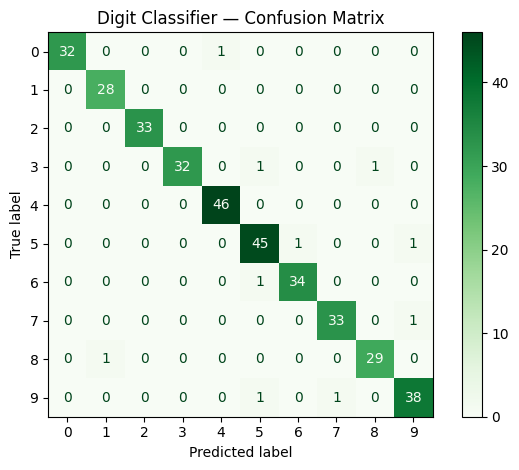


Feature Importances:
      feature  importance
21  pixel_2_5    0.051494
36  pixel_4_4    0.044599
43  pixel_5_3    0.040084
26  pixel_3_2    0.037382
42  pixel_5_2    0.036697
..        ...         ...
24  pixel_3_0    0.000015
0   pixel_0_0    0.000000
39  pixel_4_7    0.000000
32  pixel_4_0    0.000000
56  pixel_7_0    0.000000

[64 rows x 2 columns]


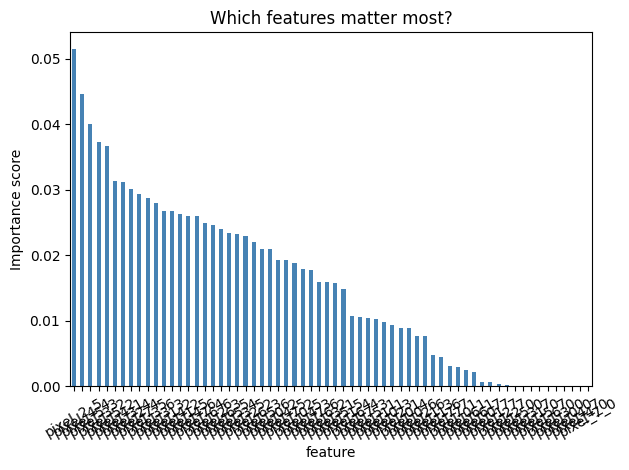

In [ ]:
# ============================================================
# ROUND 2 — CHECKPOINT 6 — Full Evaluation + Feature Importance
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# Step 1 — Retrain winning model (Random Forest) on train set
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])
#final_model.fit(___, ___)
final_model.fit(X_train, y_train)

# Step 2 — Predict
y_pred = final_model.predict(X_test)

# Step 3 — Classification report
print("Classification Report:")
print(classification_report(
    y_test, y_pred, target_names=[str(x) for x in data.target_names]
))

# Step 4 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[str(x) for x in data.target_names]
    )
disp.plot(cmap='Greens')
plt.title("Digit Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()

# Step 5 — NEW — Feature Importance
# Extract the trained model from inside the pipeline
rf_model = final_model.named_steps['model']

# Get importance scores
importances = rf_model.feature_importances_

# Build a DataFrame for easy reading
feature_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nFeature Importances:")
print(feature_df)

# Step 6 — Plot feature importances
feature_df.plot(
    kind='bar',
    x='feature',
    y='importance',
    legend=False,
    color='steelblue'
)
plt.title("Which features matter most?")
plt.ylabel("Importance score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()